# ==========================================
# Breast Cancer Subtype Classification
# Data Preprocessing
# =========================================

In [1]:

import pandas as pd
import numpy as np
import gzip
import re

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

In [2]:
FILE_PATH = r"C:\Research_Paper_Project\GSE45827_dataset_series_matrix.txt.gz"

In [3]:
# Reading the compressed GEO file

with gzip.open(FILE_PATH, "rt") as file:
    lines = file.readlines()

print("Total lines in GEO file:", len(lines))

Total lines in GEO file: 29943


In [4]:
sample_titles = []
sample_subtypes = []

for line in lines:

    # Sample titles
    if line.startswith("!Sample_title"):
        sample_titles = line.strip().split("\t")[1:]

    # Tumor subtype
    if line.startswith("!Sample_characteristics_ch1") and "tumor subtype:" in line:

        values = line.strip().split("\t")[1:]

        for value in values:

            subtype = value.replace('"', "")
            subtype = subtype.replace("tumor subtype: ", "")

            sample_subtypes.append(subtype)

print("Number of samples :", len(sample_titles))
print("Number of labels  :", len(sample_subtypes))

Number of samples : 155
Number of labels  : 155


In [5]:
start = None
end = None

for i, line in enumerate(lines):

    if line.startswith("!series_matrix_table_begin"):
        start = i + 1

    if line.startswith("!series_matrix_table_end"):
        end = i

print(start, end)

68 29942


In [6]:
from io import StringIO

expression_text = "".join(lines[start:end])

expression_df = pd.read_csv(
    StringIO(expression_text),
    sep="\t"
)

print(expression_df.shape)
expression_df.head()

(29873, 156)


,ID_REF,GSM1116084,GSM1116085,GSM1116086,GSM1116087,GSM1116088,GSM1116089,GSM1116090,GSM1116091,GSM1116092,...,GSM1116229,GSM1116230,GSM1116231,GSM1116232,GSM1116233,GSM1116234,GSM1116235,GSM1116236,GSM1116237,GSM1116238
0,1007_s_at,9.47065,9.67440,10.20800,10.11420,11.16360,10.00690,9.53932,9.00187,6.54074,...,9.96811,10.10680,10.03290,9.84599,10.75850,10.55470,9.45290,10.80010,10.04640,11.42010
1,1053_at,8.36311,8.72194,7.78601,9.44537,7.71242,7.84274,7.56238,8.01540,9.37874,...,7.25745,7.54377,7.41607,5.83454,8.83376,6.88277,6.83700,7.29371,7.71122,7.63877
2,117_at,5.95426,7.02523,6.39671,4.56023,5.29008,6.21590,6.42180,6.23554,5.43541,...,8.35832,6.98743,4.50611,4.78051,4.55847,4.14597,6.10766,5.41169,4.57742,4.67159
3,1294_at,6.02119,7.24581,6.85310,5.42786,7.51120,5.79719,7.36700,7.17268,7.72472,...,7.18591,7.74070,7.44448,7.03001,6.87039,6.37882,6.99674,8.37598,6.56774,7.40374
4,1316_at,3.22997,3.29352,3.26204,3.34766,3.59086,3.40108,3.27663,3.14212,3.28420,...,3.50312,3.57309,3.31572,3.70289,4.82208,3.55309,3.23899,3.84879,3.28091,3.24882


In [7]:
# Removing columns with null values
expression_df = expression_df.dropna(axis=1, how="all")

print(expression_df.shape)

(29873, 156)


In [8]:
expression_df = expression_df.set_index("ID_REF")

expression_df.head()

,GSM1116084,GSM1116085,GSM1116086,GSM1116087,GSM1116088,GSM1116089,GSM1116090,GSM1116091,GSM1116092,GSM1116093,...,GSM1116229,GSM1116230,GSM1116231,GSM1116232,GSM1116233,GSM1116234,GSM1116235,GSM1116236,GSM1116237,GSM1116238
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,9.47065,9.67440,10.20800,10.11420,11.16360,10.00690,9.53932,9.00187,6.54074,10.35510,...,9.96811,10.10680,10.03290,9.84599,10.75850,10.55470,9.45290,10.80010,10.04640,11.42010
1053_at,8.36311,8.72194,7.78601,9.44537,7.71242,7.84274,7.56238,8.01540,9.37874,9.45426,...,7.25745,7.54377,7.41607,5.83454,8.83376,6.88277,6.83700,7.29371,7.71122,7.63877
117_at,5.95426,7.02523,6.39671,4.56023,5.29008,6.21590,6.42180,6.23554,5.43541,3.85652,...,8.35832,6.98743,4.50611,4.78051,4.55847,4.14597,6.10766,5.41169,4.57742,4.67159
1294_at,6.02119,7.24581,6.85310,5.42786,7.51120,5.79719,7.36700,7.17268,7.72472,4.79560,...,7.18591,7.74070,7.44448,7.03001,6.87039,6.37882,6.99674,8.37598,6.56774,7.40374
1316_at,3.22997,3.29352,3.26204,3.34766,3.59086,3.40108,3.27663,3.14212,3.28420,3.27900,...,3.50312,3.57309,3.31572,3.70289,4.82208,3.55309,3.23899,3.84879,3.28091,3.24882


In [9]:
expression_df = expression_df.T

print(expression_df.shape)

(155, 29873)


In [10]:
expression_df["Subtype"] = sample_subtypes

expression_df.head()

ID_REF,1007_s_at,1053_at,117_at,1294_at,1316_at,1405_i_at,1438_at,1487_at,1552256_a_at,1552257_a_at,...,89476_r_at,90265_at,90610_at,91617_at,91684_g_at,91703_at,91816_f_at,91826_at,91952_at,Subtype
GSM1116084,9.47065,8.36311,5.95426,6.02119,3.22997,10.82220,4.39698,6.65320,10.91320,10.07510,...,7.67662,8.58529,6.58532,6.47111,8.05685,5.51480,6.04568,5.90542,4.34839,Basal
GSM1116085,9.67440,8.72194,7.02523,7.24581,3.29352,9.29455,6.68936,7.20820,9.32204,9.34476,...,7.32080,6.21915,6.81551,6.54900,6.62661,5.58320,5.67661,6.68275,4.94622,Basal
GSM1116086,10.20800,7.78601,6.39671,6.85310,3.26204,9.45727,5.46440,6.68974,7.73131,8.43573,...,7.53787,7.86806,6.90606,6.32751,7.51148,5.85887,3.14257,7.77158,3.58973,Her2
GSM1116087,10.11420,9.44537,4.56023,5.42786,3.34766,11.51270,5.29748,6.87276,10.39210,9.63893,...,7.86515,8.79839,7.09756,6.03216,7.38772,4.55774,3.04537,6.47312,4.55167,Basal
GSM1116088,11.16360,7.71242,5.29008,7.51120,3.59086,8.83075,6.81821,6.45744,7.05836,9.37463,...,7.33174,7.01692,5.51992,6.09710,6.41229,5.34572,4.33680,8.48681,4.72397,Her2


In [11]:
print("\nMissing Values")

print(expression_df.isnull().sum().sum())


Missing Values
0


In [12]:
encoder = LabelEncoder()

expression_df["Target"] = encoder.fit_transform(
    expression_df["Subtype"]
)

print("\nClasses")

print(encoder.classes_)


Classes
['Basal' 'Her2' 'Luminal A' 'Luminal B' 'N/A'
 'cell origin: Breast carcinoma' 'cell origin: Breast mammary gland']


In [13]:
X = expression_df.drop(
    columns=["Subtype", "Target"]
)

y = expression_df["Target"]

print("\nFeature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)


Feature Matrix Shape : (155, 29873)
Target Shape : (155,)


In [14]:
print("\nSubtype Distribution\n")

print(expression_df["Subtype"].value_counts())


Subtype Distribution

Subtype
Basal                                41
Her2                                 30
Luminal B                            30
Luminal A                            29
cell origin: Breast carcinoma        12
N/A                                  11
cell origin: Breast mammary gland     2
Name: count, dtype: int64


In [15]:
expression_df.to_csv(
    "processed_gene_expression.csv",
    index=True
)

print("\nProcessed dataset saved successfully!")


Processed dataset saved successfully!


In [16]:
# Rename N/A to Normal
expression_df["Subtype"] = expression_df["Subtype"].replace({
    "N/A": "Normal"
})

# Remove cell lines
expression_df = expression_df[
    ~expression_df["Subtype"].isin([
        "cell origin: Breast carcinoma",
        "cell origin: Breast mammary gland"
    ])
]

print(expression_df["Subtype"].value_counts())

Subtype
Basal        41
Her2         30
Luminal B    30
Luminal A    29
Normal       11
Name: count, dtype: int64


In [17]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

expression_df["Target"] = encoder.fit_transform(expression_df["Subtype"])

X = expression_df.drop(columns=["Subtype", "Target"])

y = expression_df["Target"]

print(X.shape)
print(y.shape)

(141, 29873)
(141,)


In [18]:
print(X.shape)
print(expression_df["Subtype"].value_counts())

(141, 29873)
Subtype
Basal        41
Her2         30
Luminal B    30
Luminal A    29
Normal       11
Name: count, dtype: int64


In [62]:
import os

os.makedirs("results", exist_ok=True)

# Save cleaned dataset
X.to_csv("results/clean_dataset.csv")

# Save labels
pd.DataFrame({
    "Subtype": y
}).to_csv("results/labels.csv", index=False)

print("Files Saved Successfully!")

Files Saved Successfully!


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [20]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

print("Number of Samples :", X.shape[0])
print("Number of Genes   :", X.shape[1])
print("Number of Classes :", len(expression_df["Subtype"].unique()))

print("\nClass Distribution\n")
print(expression_df["Subtype"].value_counts())

DATASET INFORMATION
Number of Samples : 141
Number of Genes   : 29873
Number of Classes : 5

Class Distribution

Subtype
Basal        41
Her2         30
Luminal B    30
Luminal A    29
Normal       11
Name: count, dtype: int64


In [21]:
print("\nMissing Values")

print(X.isnull().sum().sum())


Missing Values
0


In [22]:
print("\nSummary Statistics")

print(X.describe())


Summary Statistics
ID_REF   1007_s_at     1053_at      117_at     1294_at    1316_at   1405_i_at  \
count   141.000000  141.000000  141.000000  141.000000  141.00000  141.000000   
mean     10.080265    7.599933    5.691279    6.993685    3.59325    8.862113   
std       0.703055    0.907533    1.119117    1.034598    0.52991    1.927564   
min       6.540740    4.979580    3.143520    3.896670    2.71935    3.100810   
25%       9.676320    7.121970    4.832120    6.393390    3.29536    7.861220   
50%      10.124300    7.638770    5.844020    7.185910    3.44371    8.930080   
75%      10.594600    8.181650    6.282050    7.712620    3.56032   10.058800   
max      11.460100    9.454260    9.142380    8.903120    6.05066   13.183000   

ID_REF     1438_at     1487_at  1552256_a_at  1552257_a_at  ...    87100_at  \
count   141.000000  141.000000    141.000000    141.000000  ...  141.000000   
mean      4.491180    6.490659      8.874761      8.604830  ...    5.428528   
std       1.7

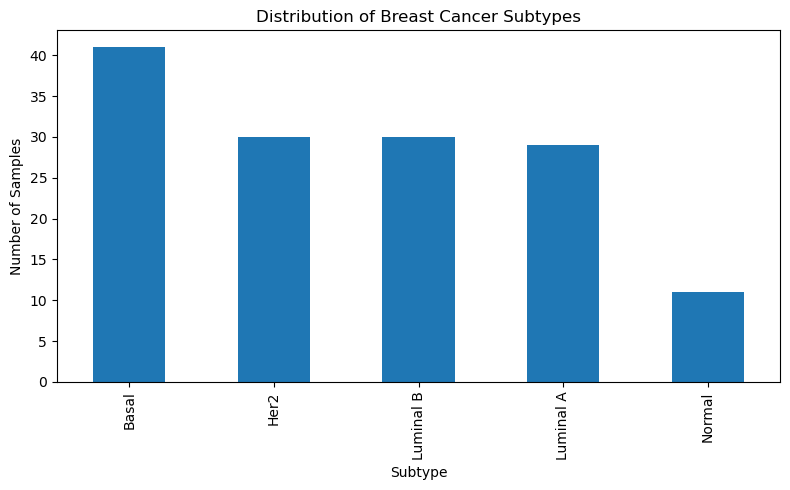

In [23]:
counts = expression_df["Subtype"].value_counts()

plt.figure(figsize=(8,5))

counts.plot(kind="bar")

plt.title("Distribution of Breast Cancer Subtypes")

plt.xlabel("Subtype")

plt.ylabel("Number of Samples")

plt.tight_layout()

plt.savefig(
    "figures/class_distribution.png",
    dpi=300
)

plt.show()

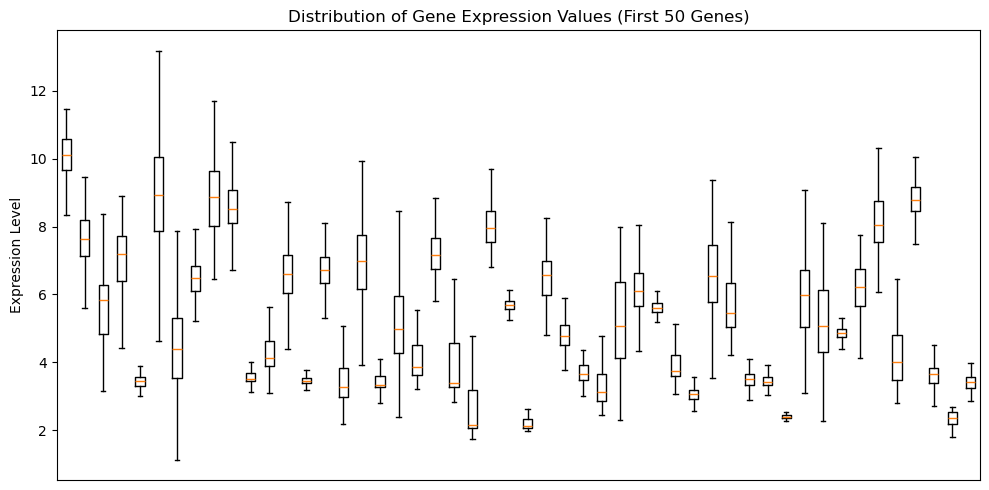

In [24]:
plt.figure(figsize=(10,5))

plt.boxplot(
    X.iloc[:,0:50],
    showfliers=False
)

plt.title("Distribution of Gene Expression Values (First 50 Genes)")

plt.ylabel("Expression Level")

plt.xticks([])

plt.tight_layout()

plt.savefig(
    "figures/gene_expression_distribution.png",
    dpi=300
)

plt.show()

In [25]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [26]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance")

print(pca.explained_variance_ratio_)

Explained Variance
[0.14057667 0.09382278]


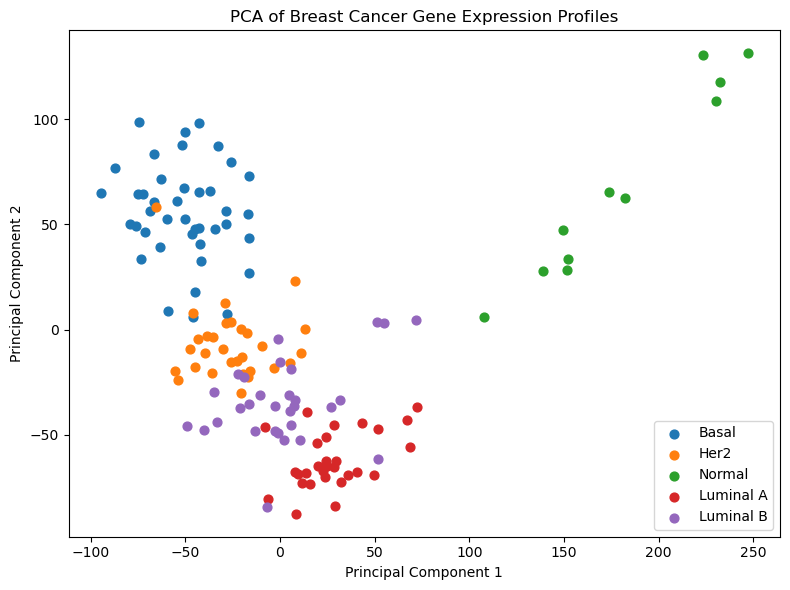

In [27]:
plt.figure(figsize=(8,6))

classes = expression_df["Subtype"].unique()

for subtype in classes:

    mask = expression_df["Subtype"] == subtype

    plt.scatter(
        X_pca[mask,0],
        X_pca[mask,1],
        label=subtype,
        s=40
    )

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("PCA of Breast Cancer Gene Expression Profiles")

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/pca_plot.png",
    dpi=300
)

plt.show()

In [28]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

In [29]:
expression_df.to_csv(
    "results/clean_dataset.csv",
    index=True
)

print("Dataset Saved")

Dataset Saved


# Principal Component 1 (PC1) explains about 14.06% of the total variation in the gene expression data.
# Principal Component 2 (PC2) explains about 9.38% of the variation.

≈ 23.44% of the total variance.

This is completely normal for gene expression datasets because they contain nearly 30,000 gene features. Biological data are highly complex, so it's expected that the first two principal components don't explain most of the variance.The first two principal components explained approximately 23.4% of the total variance in the gene expression dataset, reflecting the high dimensionality and biological complexity of transcriptomic data."

In [30]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(112, 29873)
(29, 29873)


In [32]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [33]:
pipe_lr = Pipeline([
    ("feature_selection", SelectKBest(score_func=f_classif, k=500)),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=5000))
])

In [34]:
pipe_svm = Pipeline([
    ("feature_selection", SelectKBest(f_classif, k=500)),
    ("scaler", StandardScaler()),
    ("classifier", SVC(probability=True))
])

In [35]:
pipe_rf = Pipeline([
    ("feature_selection", SelectKBest(f_classif, k=500)),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [36]:
pipe_rf = Pipeline([
    ("feature_selection", SelectKBest(f_classif, k=500)),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [37]:
pipe_xgb = Pipeline([
    ("feature_selection", SelectKBest(f_classif, k=500)),
    ("classifier", XGBClassifier(
        eval_metric="mlogloss",
        random_state=42
    ))
])

In [38]:
# hypertension grid for each parameters
param_lr = {
    "classifier__C":[0.1,1,10]
}

In [39]:
param_svm = {

    "classifier__C":[0.1,1,10],

    "classifier__kernel":[
        "linear",
        "rbf"
    ]
}

In [40]:
param_rf = {

    "classifier__n_estimators":[100,200],

    "classifier__max_depth":[
        None,
        10,
        20
    ]
}

In [41]:
param_xgb = {

    "classifier__n_estimators":[100,200],

    "classifier__max_depth":[3,5],

    "classifier__learning_rate":[
        0.01,
        0.1
    ]
}

In [42]:
models = {

    "Logistic Regression":(
        pipe_lr,
        param_lr
    ),

    "Support Vector Machine":(
        pipe_svm,
        param_svm
    ),

    "Random Forest":(
        pipe_rf,
        param_rf
    ),

    "XGBoost":(
        pipe_xgb,
        param_xgb
    )

}

In [43]:
results = {}

best_models = {}

for name,(pipeline,params) in models.items():

    print("="*60)
    print(name)
    print("="*60)

    grid = GridSearchCV(

        pipeline,

        params,

        cv=cv,

        scoring="accuracy",

        n_jobs=-1

    )

    grid.fit(X_train,y_train)

    best_models[name]=grid.best_estimator_

    prediction = grid.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    cv_score = cross_val_score(

        grid.best_estimator_,

        X_train,

        y_train,

        cv=cv,

        scoring="accuracy"

    )

    results[name]={

        "Test Accuracy":accuracy,

        "CV Mean":cv_score.mean(),

        "CV Std":cv_score.std()

    }

    print("Best Parameters")

    print(grid.best_params_)

    print()

    print("Test Accuracy")

    print(round(accuracy,4))

    print()

    print("Cross Validation")

    print(round(cv_score.mean(),4))

    print("±")

    print(round(cv_score.std(),4))

Logistic Regression
Best Parameters
{'classifier__C': 10}

Test Accuracy
1.0

Cross Validation
0.9462
±
0.0186
Support Vector Machine
Best Parameters
{'classifier__C': 10, 'classifier__kernel': 'rbf'}

Test Accuracy
1.0

Cross Validation
0.9644
±
0.0178
Random Forest
Best Parameters
{'classifier__max_depth': None, 'classifier__n_estimators': 200}

Test Accuracy
0.9655

Cross Validation
0.9462
±
0.0447
XGBoost
Best Parameters
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}

Test Accuracy
0.9655

Cross Validation
0.9012
±
0.0522


In [44]:
results_df = pd.DataFrame(results).T

results_df

,Test Accuracy,CV Mean,CV Std
Logistic Regression,1.000000,0.946245,0.018598
Support Vector Machine,1.000000,0.964427,0.017809
Random Forest,0.965517,0.946245,0.044708
XGBoost,0.965517,0.901186,0.052243


In [45]:
import os
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

In [46]:
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

In [47]:
from sklearn.metrics import accuracy_score

for name, model in best_models.items():

    print("="*60)
    print(name)
    print("="*60)

    y_pred = model.predict(X_test)

    print(classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    ))

Logistic Regression
              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00         9
        Her2       1.00      1.00      1.00         6
   Luminal A       1.00      1.00      1.00         6
   Luminal B       1.00      1.00      1.00         6
      Normal       1.00      1.00      1.00         2

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29

Support Vector Machine
              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00         9
        Her2       1.00      1.00      1.00         6
   Luminal A       1.00      1.00      1.00         6
   Luminal B       1.00      1.00      1.00         6
      Normal       1.00      1.00      1.00         2

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00 

<Figure size 600x600 with 0 Axes>

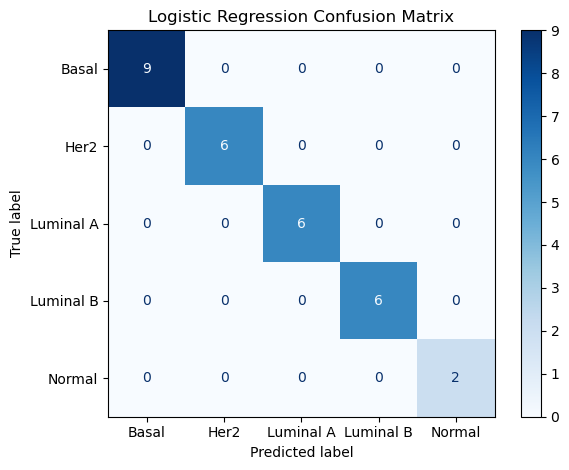

<Figure size 600x600 with 0 Axes>

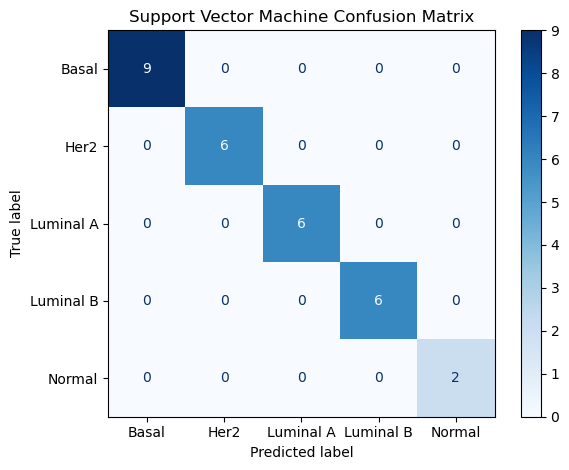

<Figure size 600x600 with 0 Axes>

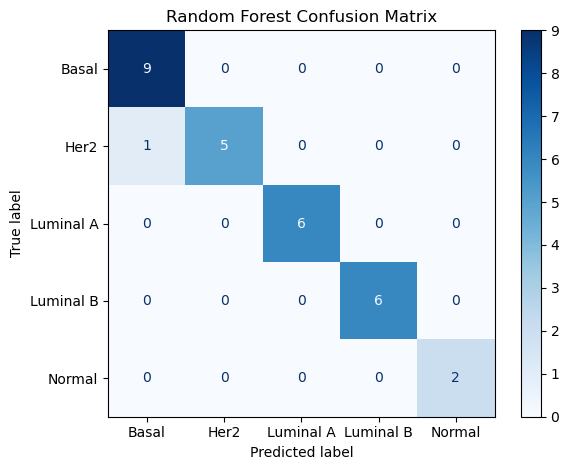

<Figure size 600x600 with 0 Axes>

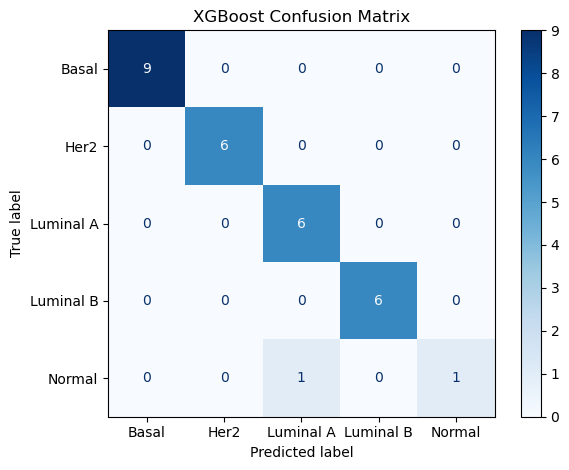

In [48]:
for name, model in best_models.items():

    y_pred = model.predict(X_test)

    plt.figure(figsize=(6,6))

    disp = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=encoder.classes_,
        cmap="Blues"
    )

    plt.title(f"{name} Confusion Matrix")

    plt.tight_layout()

    filename = name.replace(" ", "_")

    plt.savefig(
        f"figures/{filename}_confusion_matrix.png",
        dpi=300
    )

    plt.show()

In [49]:
classes = np.unique(y)

y_test_bin = label_binarize(y_test, classes=classes)

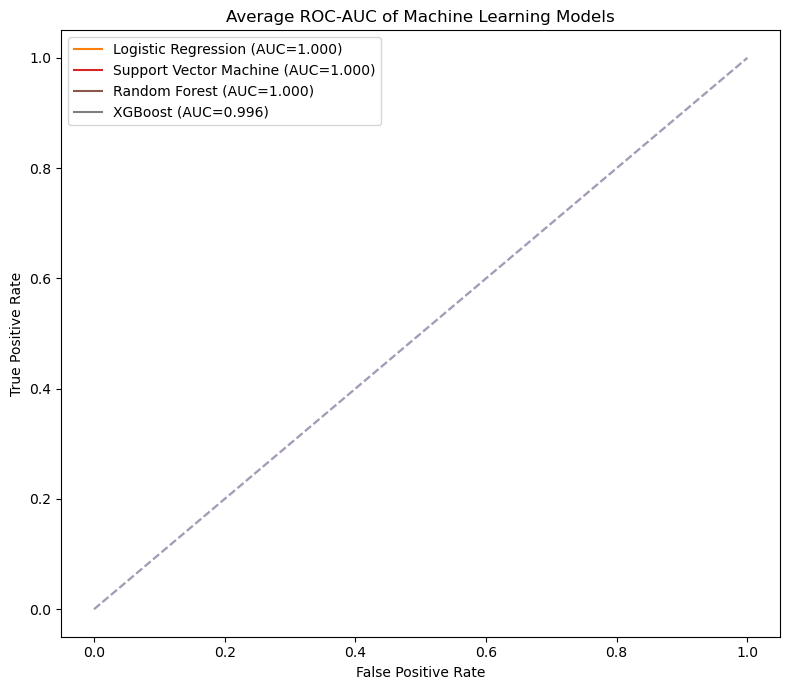

In [50]:
plt.figure(figsize=(8,7))

for name, model in best_models.items():

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)

    else:
        y_score = model.decision_function(X_test)

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(len(classes)):

        fpr[i], tpr[i], _ = roc_curve(
            y_test_bin[:, i],
            y_score[:, i]
        )

        roc_auc[i] = auc(
            fpr[i],
            tpr[i]
        )

    macro_auc = np.mean(list(roc_auc.values()))

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--",
        alpha=0.3
    )

    plt.plot(
        [],
        [],
        label=f"{name} (AUC={macro_auc:.3f})"
    )

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Average ROC-AUC of Machine Learning Models")

plt.legend()

plt.tight_layout()

plt.savefig(
    "figures/roc_comparison.png",
    dpi=300
)

plt.show()

In [51]:
reports = {}

for name, model in best_models.items():

    prediction = model.predict(X_test)

    report = classification_report(
        y_test,
        prediction,
        target_names=encoder.classes_,
        output_dict=True
    )

    reports[name] = report

In [52]:
import pandas as pd

for model_name in reports:

    df = pd.DataFrame(reports[model_name]).transpose()

    filename = model_name.replace(" ", "_")

    df.to_csv(
        f"results/{filename}_classification_report.csv"
    )

In [53]:
# Identifying Important Genes
# Best-performing model
best_model = best_models["Support Vector Machine"]

In [54]:
selector = best_model.named_steps["feature_selection"]

In [55]:
selected_indices = selector.get_support(indices=True)

print("Number of Selected Genes:", len(selected_indices))

Number of Selected Genes: 500


In [56]:
gene_names = X.columns

selected_gene_names = gene_names[selected_indices]

selected_gene_names[:20]

Index(['1053_at', '1552509_a_at', '1552617_a_at', '1552619_a_at', '1552733_at',
       '1553243_at', '1554271_a_at', '1554365_a_at', '1554408_a_at',
       '1554572_a_at', '1554696_s_at', '1554768_a_at', '1554804_a_at',
       '1555278_a_at', '1555618_s_at', '1555707_at', '1555730_a_at',
       '1555758_a_at', '1555760_a_at', '1555780_a_at'],
      dtype='object', name='ID_REF')

In [57]:
selected_df = pd.DataFrame({
    "Probe_ID": selected_gene_names
})

selected_df.head()

,Probe_ID
0,1053_at
1,1552509_a_at
2,1552617_a_at
3,1552619_a_at
4,1552733_at


In [58]:
selected_df.to_csv(
    "results/selected_genes.csv",
    index=False
)

print("Selected genes saved.")

Selected genes saved.


In [59]:
scores = selector.scores_

selected_scores = scores[selected_indices]

importance_df = pd.DataFrame({
    "Probe_ID": selected_gene_names,
    "F_Score": selected_scores
})

importance_df = importance_df.sort_values(
    by="F_Score",
    ascending=False
)

importance_df.head(20)

,Probe_ID,F_Score
240,211565_at,481.216276
488,243689_s_at,297.991104
32,1562755_at,276.654465
344,220232_at,208.893237
453,233103_at,204.729457
388,224012_at,181.966976
30,1561754_at,178.021302
273,213715_s_at,168.059093
31,1562527_at,166.202618
466,235849_at,157.045139


In [60]:
importance_df.to_csv(
    "results/top_ranked_genes.csv",
    index=False
)

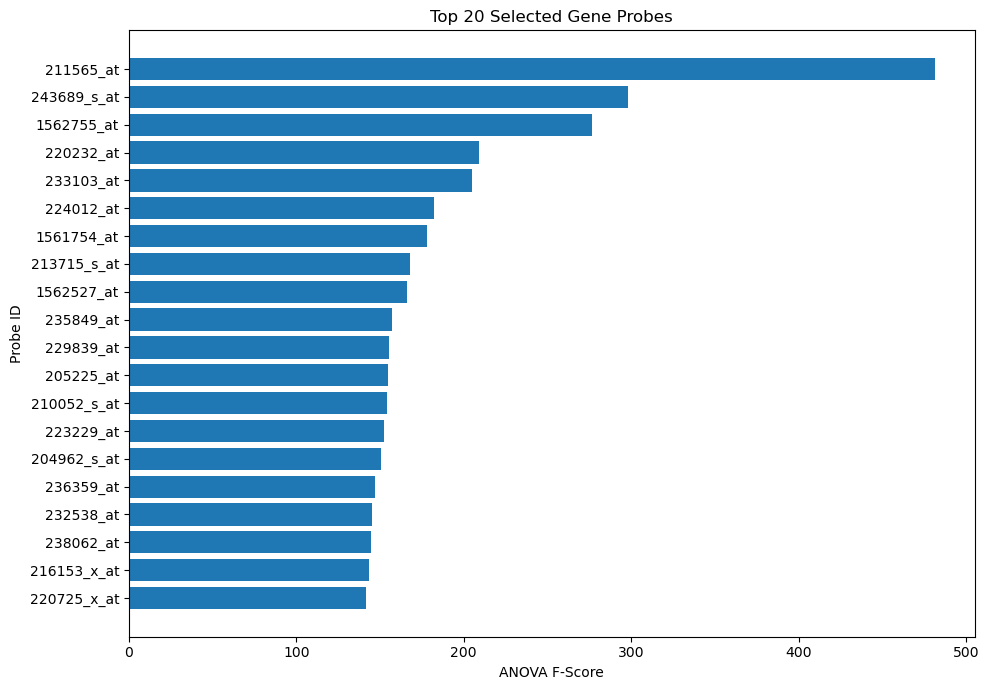

In [61]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,7))

plt.barh(
    top20["Probe_ID"],
    top20["F_Score"]
)

plt.xlabel("ANOVA F-Score")
plt.ylabel("Probe ID")
plt.title("Top 20 Selected Gene Probes")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "figures/top20_genes.png",
    dpi=300
)

plt.show()